In [1]:
import os
from pathlib import Path

import polars as pl
import pandas as pd
import numpy as np

from mllabs.processor import PolarsLoader, PandasConverter, ExprProcessor
from mllabs import Experimenter, Connector
from mllabs.collector import MetricCollector, ModelAttrCollector

from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score

import lightgbm as lgb

import matplotlib.pyplot as plt
import seaborn as sns

2026-04-15 10:17:31.496853: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [6]:
data_path = Path('data')

loader = make_pipeline(
    PolarsLoader(predefined_types={'id': pl.Int64}),
    PandasConverter(index_col = 'id')
)
df_train = loader.fit_transform([data_path / 'train.csv'])
df_test = loader.transform([data_path / 'test.csv'])
df_org = loader.transform([data_path / 'irrigation_prediction.csv'])
df_org = df_org.set_index(pd.Index(-np.arange(1, len(df_org) + 1), name = 'id'))

# Oridinal 변수, 정도에 따른 수치화
df_train[y] = df_train[y].map({'Low': 0, 'Medium': 1, 'High': 2}).astype('int')
df_org[y] = df_org[y].map({'Low': 0, 'Medium': 1, 'High': 2}).astype('int')

y = 'Irrigation_Need'
X_cat = ['Crop_Growth_Stage', 'Crop_Type', 'Irrigation_Type', 'Mulching_Used', 'Region', 'Season', 'Soil_Type', 'Water_Source']
X_num = ['Electrical_Conductivity', 'Field_Area_hectare', 'Humidity', 'Organic_Carbon', 'Previous_Irrigation_mm', 'Rainfall_mm', 
         'Soil_Moisture', 'Soil_pH', 'Sunlight_Hours', 'Temperature_C','Wind_Speed_kmh']
X_all = X_num + X_cat

## 입력 데이터에 Train과 Test의 차이 확인

In [3]:
df_train.shape, df_test.shape

((630000, 20), (270000, 19))

In [5]:
df_diff = pd.concat([
    df_train.drop(columns=y).assign(is_train = True),
    df_test.assign(is_train = False),
])

In [6]:
if not os.path.exists('exp/diff'):
    e_diff = Experimenter.create(df_diff, 'exp/diff')
    e_diff.set_grp('clf', method = 'predict_proba', role = 'head', edges = {'y': [(None, 'is_train')]})
    e_diff.add_collector(
        MetricCollector(
            'AUC', Connector(edges = {'y': [(None, 'is_train')]}, role = 'head'), slice(-1, None), roc_auc_score, include_train = True
        )
    )
    e_diff.set_node('lgb', grp='clf', processor=lgb.LGBMClassifier, edges={'X': [(None, X_all)]}, params={'verbose': -1})
    e_diff.exp(finalize=True)
else:
    e_diff = Experimenter.load('exp/diff', df_diff)
e_diff.get_collector('AUC').get_metrics_agg()[0]

Loaded: 1 node(s), 1 group(s), 1 fold(s)


,test,train
lgb,0.498932,0.576174


- Train과 Test를 분류하기 어려움 => 분포의 차이는 없음. 

- Test의 분포를 따로 비교할 필요는 보이지 않음

In [7]:
df_train[X_all].value_counts().max()

np.int64(1)

In [8]:
df_diff.drop_duplicates().shape

(900000, 20)

- train 내에서도, 중복된 입력 test와도 중복된 입력을 미존재

In [9]:
del df_diff

## Org와 Train과의 분포 차이 확인

In [10]:
df_diff = pd.concat([
    df_train.assign(is_org = False),
    df_org.assign(is_org = True),
])

In [11]:
df_diff['is_org'].value_counts()

is_org
False    630000
True      10000
Name: count, dtype: int64

In [12]:
if not os.path.exists('exp/diff_org'):
    e_diff = Experimenter.create(df_diff, 'exp/diff_org')
    e_diff.set_grp('clf', method = 'predict_proba', role = 'head', edges = {'y': [(None, 'is_org')]})
    e_diff.add_collector(
        MetricCollector(
            'AUC', Connector(edges = {'y': [(None, 'is_org')]}, role = 'head'), slice(-1, None), roc_auc_score, include_train = True
        )
    )
    e_diff.add_collector(
        ModelAttrCollector('feat_imp', Connector(processor=lgb.LGBMClassifier), result_key = 'feature_importances')
    )
    e_diff.set_node('lgb', grp='clf', processor=lgb.LGBMClassifier, edges={'X': [(None, X_all + [y])]}, params={'verbose': -1})
    e_diff.exp(finalize = True)
else:
    e_diff = Experimenter.load('exp/diff_org', df_diff)
e_diff.get_collector('AUC').get_metrics_agg()[0]

Loaded: 1 node(s), 1 group(s), 1 fold(s)


,test,train
lgb,0.707292,0.800814


In [13]:
e_diff.get_collector('feat_imp').get_attrs_agg('lgb').sort_values(ascending = False)

Previous_Irrigation_mm     373.0
Rainfall_mm                347.0
Soil_pH                    284.0
Humidity                   253.0
Electrical_Conductivity    250.0
Soil_Moisture              246.0
Temperature_C              232.0
Organic_Carbon             228.0
Wind_Speed_kmh             219.0
Sunlight_Hours             199.0
Field_Area_hectare         187.0
Irrigation_Need             62.0
Season                      35.0
Crop_Growth_Stage           27.0
Mulching_Used               27.0
Region                       9.0
Irrigation_Type              8.0
Crop_Type                    7.0
Soil_Type                    6.0
Water_Source                 1.0
dtype: float64

## 수치형 변수

In [39]:
df_train[X_num].describe().T.join(
    df_train[X_num].nunique().rename('nunique')
)

,count,mean,std,min,25%,50%,75%,max,nunique
Electrical_Conductivity,630000.0,1.744605,0.952321,0.10,0.930000,1.740000,2.580000,3.500000,341
Field_Area_hectare,630000.0,7.517745,4.218124,0.30,3.880000,7.380000,11.140000,15.000000,1466
Humidity,630000.0,61.563175,19.708153,25.00,45.389999,61.650002,79.120003,94.989998,6475
Organic_Carbon,630000.0,0.922858,0.365808,0.30,0.610000,0.910000,1.220000,1.600000,131
Previous_Irrigation_mm,630000.0,62.318184,34.246941,0.02,33.139999,61.150002,92.690002,119.989998,10110
Rainfall_mm,630000.0,1462.207642,612.989746,0.38,954.570007,1467.159973,2054.280029,2499.689941,19308
Soil_Moisture,630000.0,37.304482,16.377083,8.00,23.340000,37.750000,51.270000,64.989998,5223
Soil_pH,630000.0,6.482497,0.922504,4.80,5.690000,6.440000,7.270000,8.200000,341
Sunlight_Hours,630000.0,7.513382,1.999322,4.00,5.760000,7.580000,9.250000,11.000000,701
Temperature_C,630000.0,26.998171,8.623621,12.00,19.517500,26.959999,34.540001,42.000000,2934


In [30]:
y_labels = df_train[y].unique()
y_labels

array([0, 1, 2])

### 구간화를 통한 target의 분포 확인

- 'mean': 실제로 Low, Medium, High가 정도를 나타내는 지, 아니면 Nominal한 성질이 강한지를 보기 위해, 0, 1, 2의 평균을 시각화
- 0, 1, 2: 

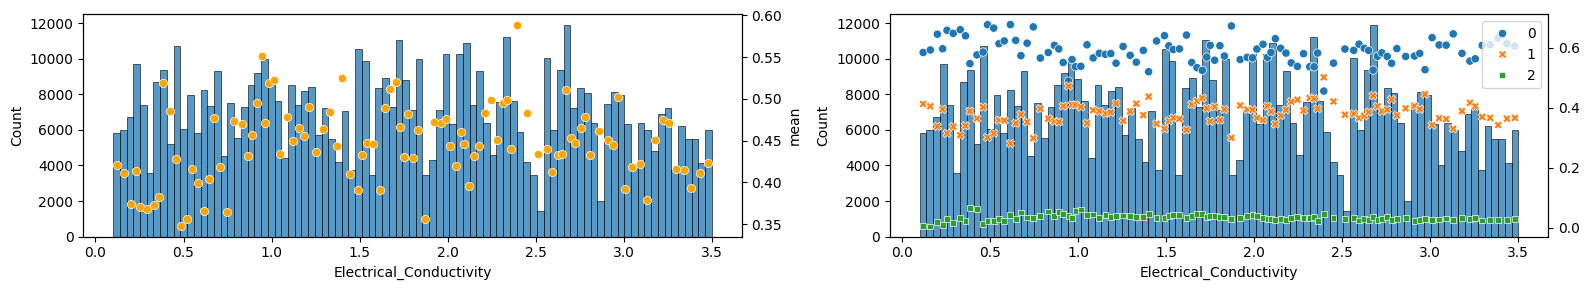

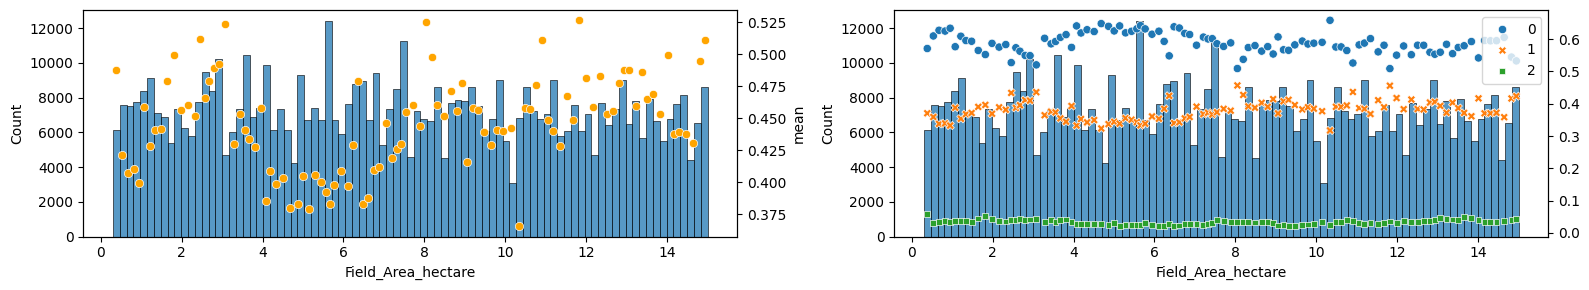

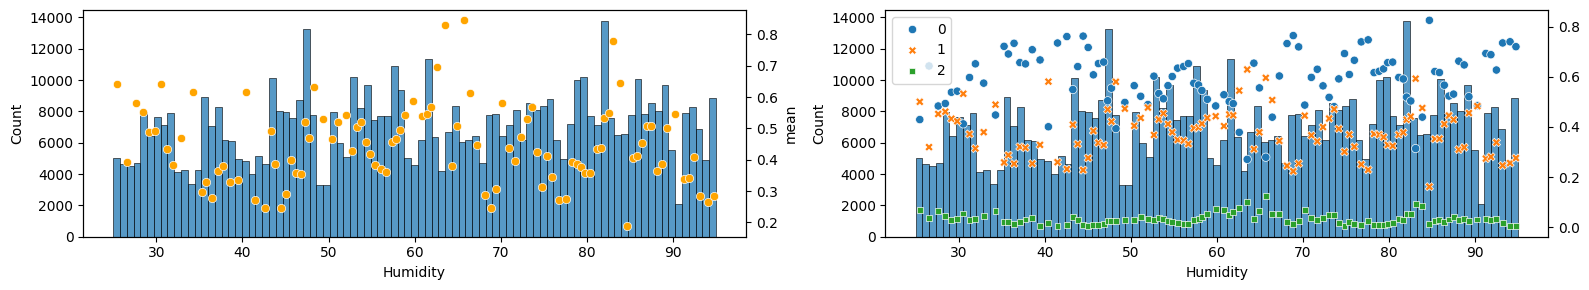

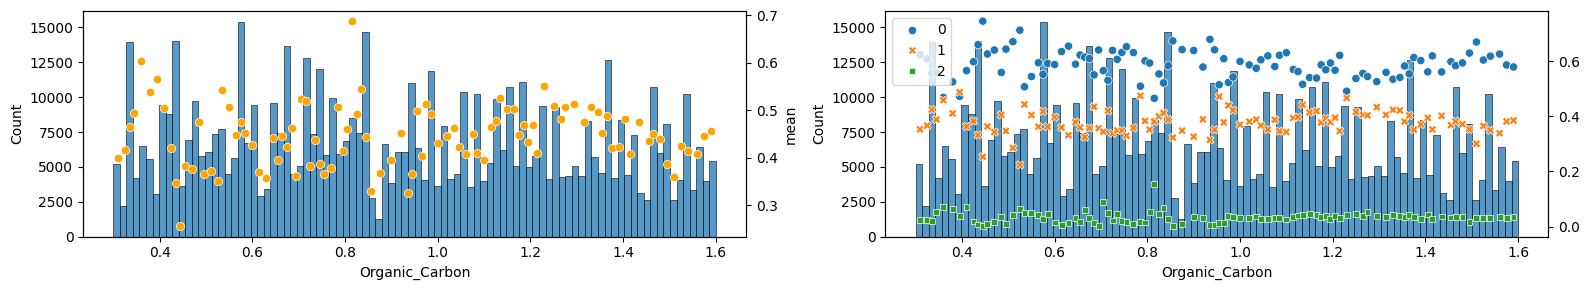

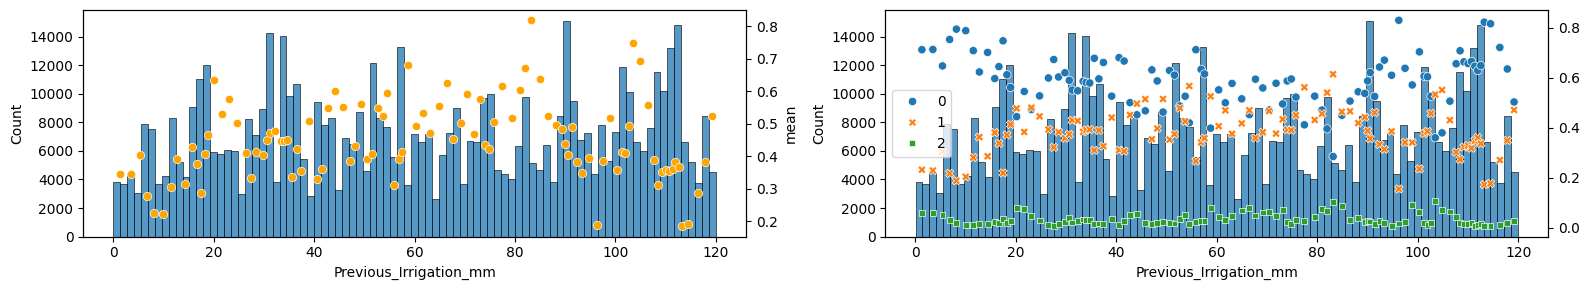

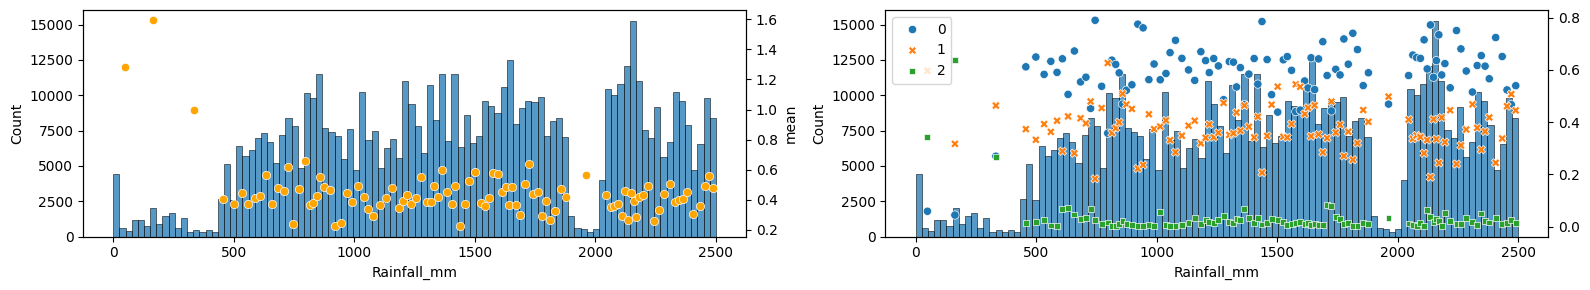

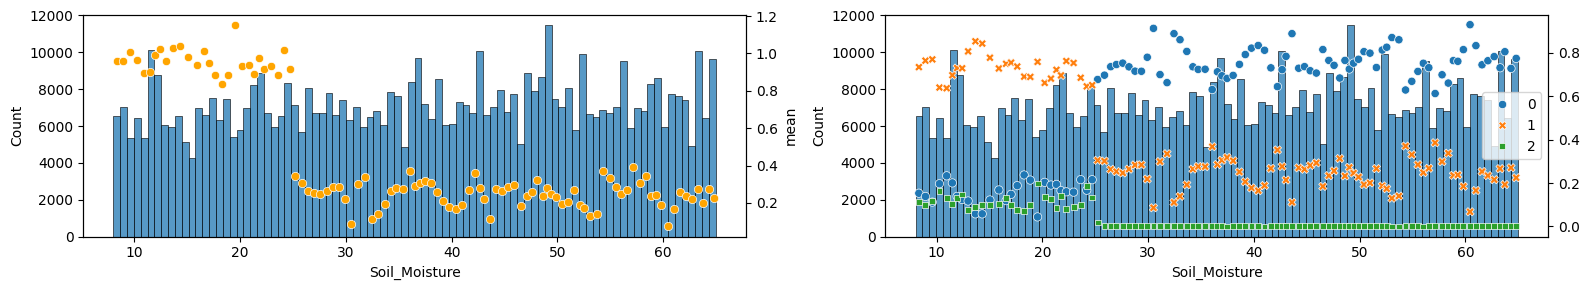

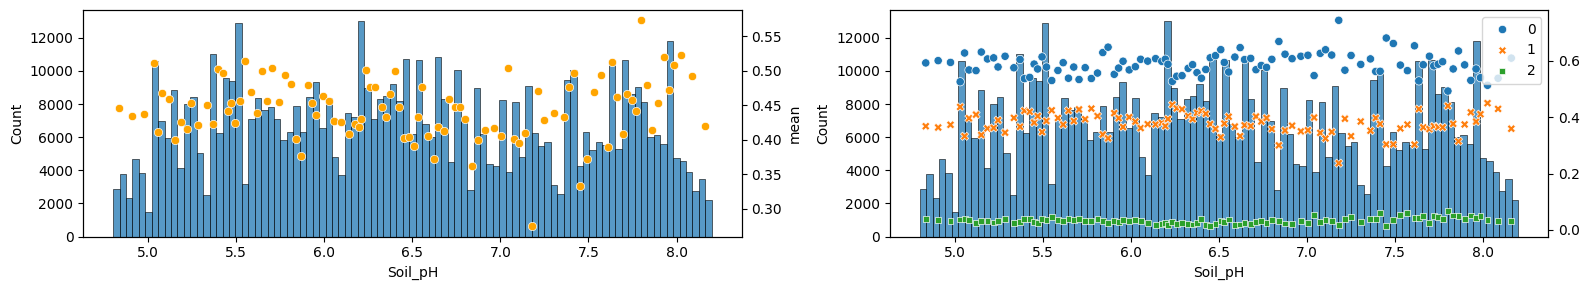

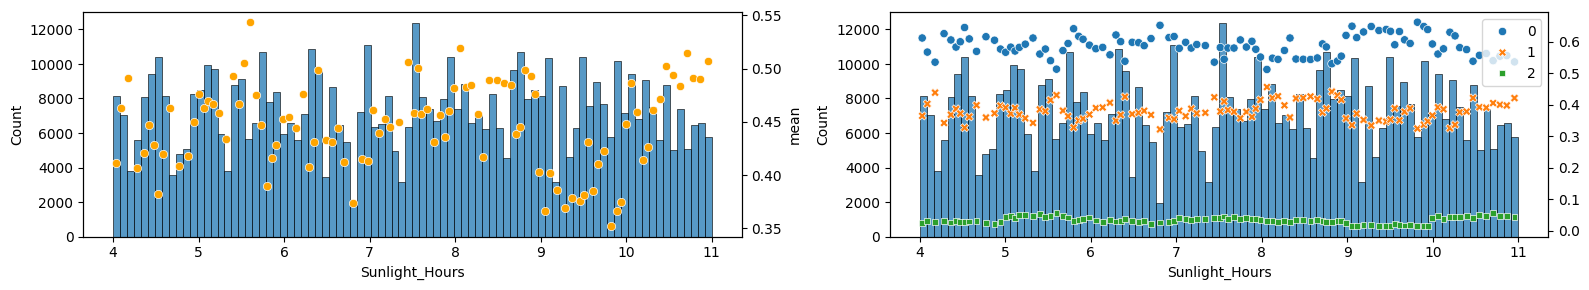

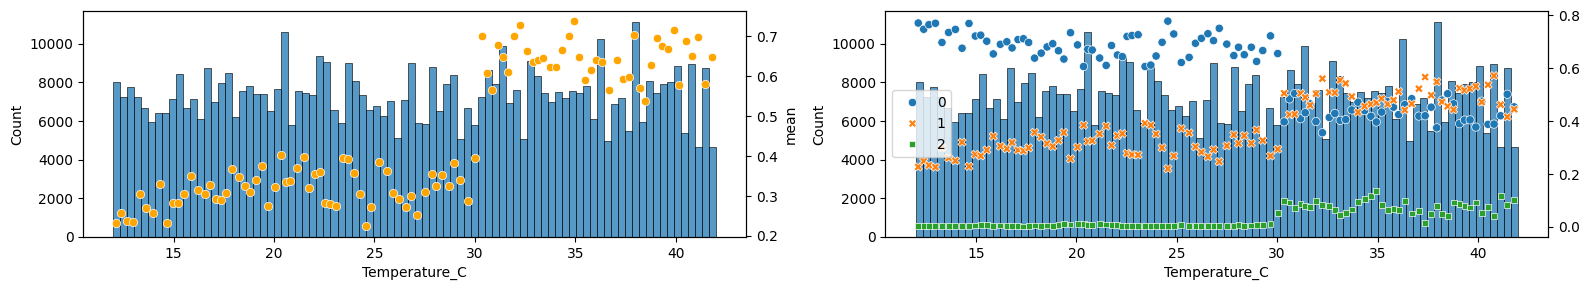

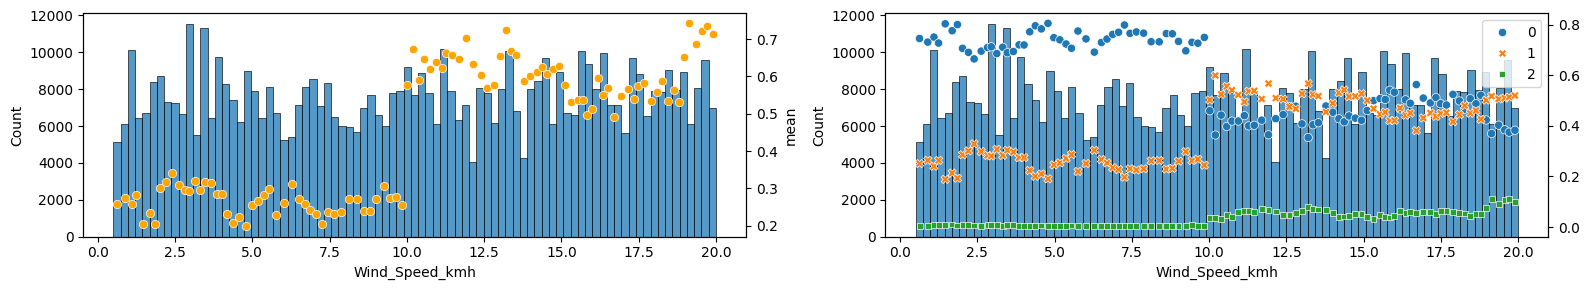

In [56]:
def plot_dist_of_target(v):
    _, axes = plt.subplots(1, 2, figsize=(16, 3))
    sns.histplot(df_train, x = v, ax = axes[0])
    sns.histplot(df_train, x = v, ax = axes[1])
    df_y = df_train.groupby(
        pd.qcut(df_train[v], q = 100, duplicates = 'drop'), observed = True
    )[y].apply(
        lambda x: pd.Series((x.mean(), (x == 0).mean(), (x == 1).mean(), (x == 2).mean()), index  = ['mean', 0, 1, 2])
    ).unstack().pipe(
        lambda x: x.set_index(
            x.index.map(lambda x: (x.left + x.right) / 2).astype('float')
        )
    )
    sns.scatterplot(x = df_y.index, y = df_y['mean'], ax = axes[0].twinx(), color = 'orange')
    sns.scatterplot(df_y[[0, 1, 2]], ax = axes[1].twinx())
    plt.tight_layout()

for i in X_num:
    plot_dist_of_target(i)